Loading dataset...

--- Dataset Overview ---
Shape of dataset (Rows, Columns): (891, 15)

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Missing Values Before Cleaning:
survived         0
pclass           0
sex              0
age            177
sibsp 

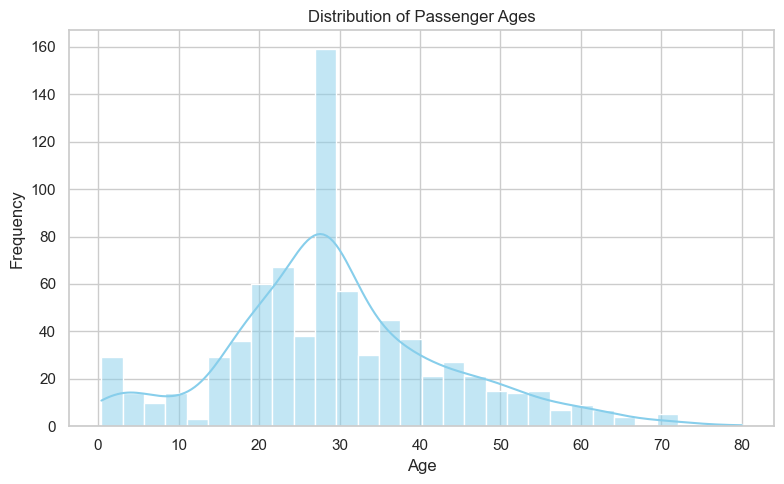

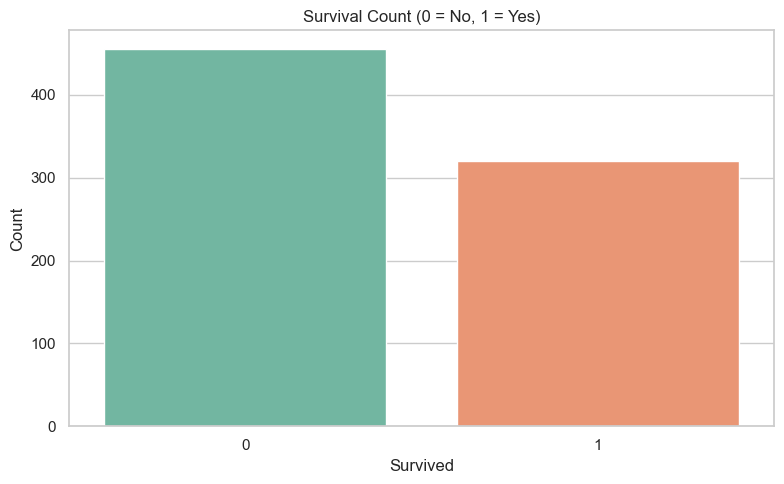

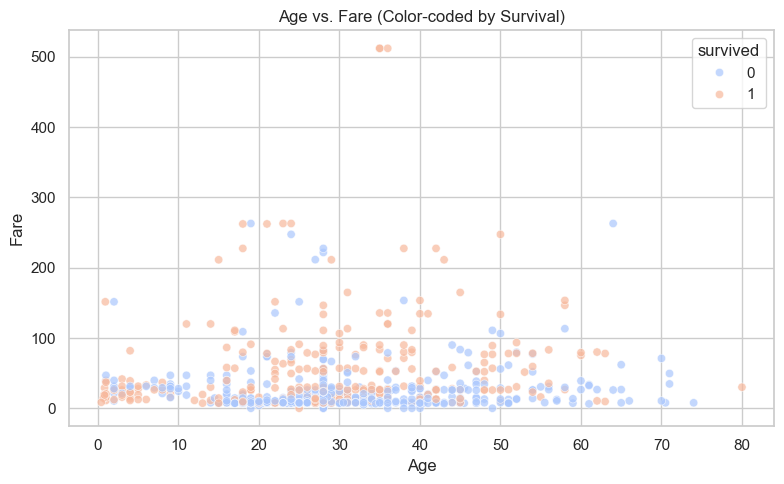

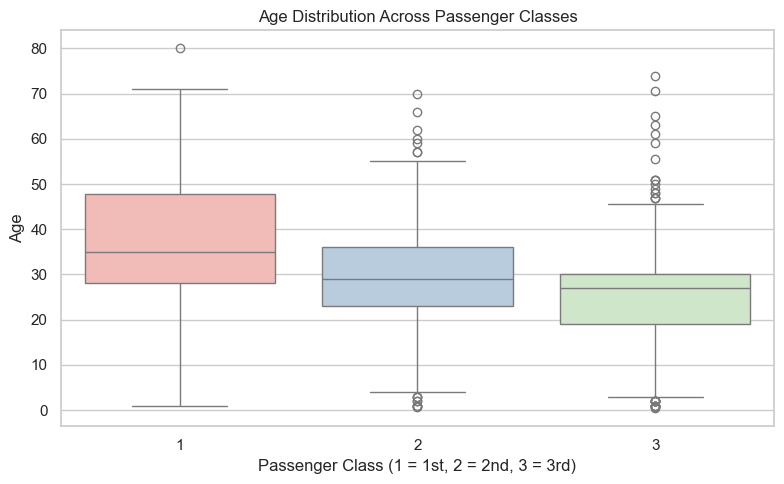

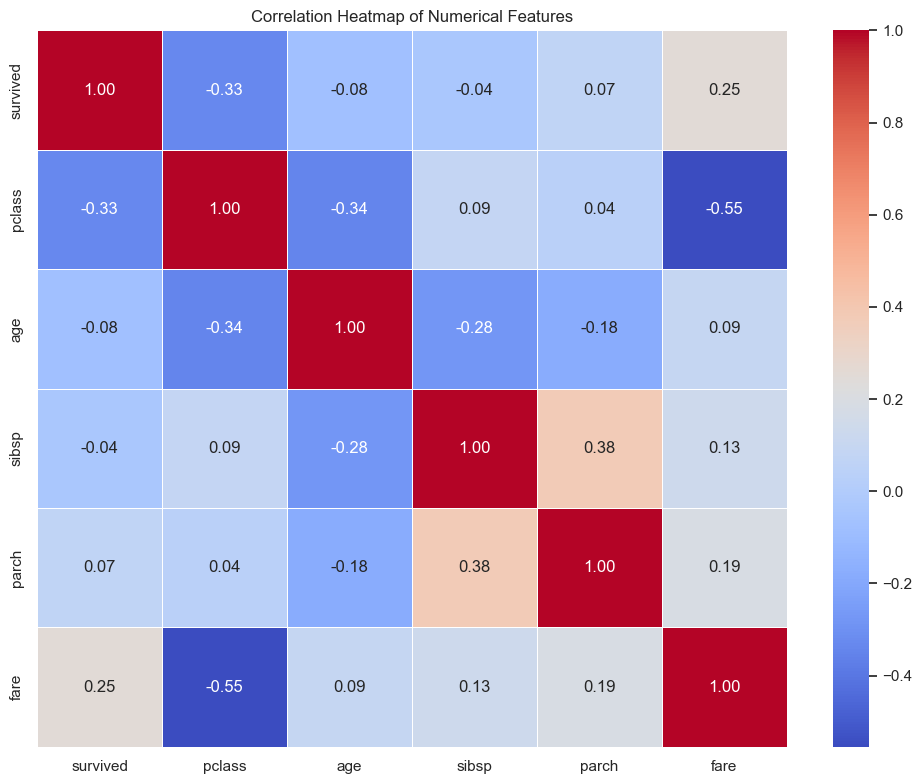


EDA Complete! All charts have been successfully saved to the 'charts' folder.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================

# Create a directory to save the charts if it doesn't already exist
output_dir = "charts"
os.makedirs(output_dir, exist_ok=True)

# Set visualization style for better-looking charts
sns.set_theme(style="whitegrid")

# Load the Titanic dataset directly from seaborn's built-in datasets
print("Loading dataset...")
df = sns.load_dataset('titanic')

# ==========================================
# 2. HIGH-LEVEL DATA OVERVIEW
# ==========================================
print("\n--- Dataset Overview ---")
print(f"Shape of dataset (Rows, Columns): {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# ==========================================
# 3. DATA CLEANING
# ==========================================
print("\n--- Cleaning Data ---")

# Fill missing numerical values ('age') with the median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing categorical values ('embarked', 'embark_town') with the mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# 'deck' has too many missing values, so we will drop that column entirely
df = df.drop(columns=['deck'])

# Remove duplicate rows if any exist
df = df.drop_duplicates()

print("Missing Values After Cleaning:")
print(df.isnull().sum())

# ==========================================
# 4. DATA VISUALIZATION (EDA)
# ==========================================
print("\n--- Generating and Saving Charts ---")

# Chart 1: Univariate Analysis - Age Distribution (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout() # Ensures labels don't get cut off
plt.savefig(f'{output_dir}/1_age_distribution.png') # Save to folder
plt.show() # Display the chart

# Chart 2: Univariate Analysis - Survival Count (Bar Chart)
plt.figure(figsize=(8, 5))
sns.countplot(x='survived', data=df, hue='survived', palette='Set2', legend=False)
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{output_dir}/2_survival_count.png')
plt.show()

# Chart 3: Bivariate Analysis - Age vs. Fare by Survival (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='fare', hue='survived', data=df, palette='coolwarm', alpha=0.7)
plt.title('Age vs. Fare (Color-coded by Survival)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.tight_layout()
plt.savefig(f'{output_dir}/3_age_vs_fare.png')
plt.show()

# Chart 4: Bivariate Analysis - Passenger Class vs. Age (Box Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='pclass', y='age', data=df, hue='pclass', palette='Pastel1', legend=False)
plt.title('Age Distribution Across Passenger Classes')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Age')
plt.tight_layout()
plt.savefig(f'{output_dir}/4_class_vs_age.png')
plt.show()

# Chart 5: Correlation Analysis (Heatmap)
# Select only numerical columns for the correlation matrix
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig(f'{output_dir}/5_correlation_heatmap.png')
plt.show()

print(f"\nEDA Complete! All charts have been successfully saved to the '{output_dir}' folder.")